<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 55.5 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [ ]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-05-08 00:09:08--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-05-08 00:09:08--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-05-08 00:09:09--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.

In [ ]:
# Posibles bandas
os.listdir("./songs_dataset/")

['bjork.txt',
 'lin-manuel-miranda.txt',
 'amy-winehouse.txt',
 'disney.txt',
 'missy-elliott.txt',
 'lorde.txt',
 'adele.txt',
 'nickelback.txt',
 'lil-wayne.txt',
 'janisjoplin.txt',
 'dr-seuss.txt',
 'michael-jackson.txt',
 'paul-simon.txt',
 'Lil_Wayne.txt',
 'eminem.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'blink-182.txt',
 'bieber.txt',
 'dickinson.txt',
 'dolly-parton.txt',
 'alicia-keys.txt',
 'nursery_rhymes.txt',
 'bob-dylan.txt',
 'cake.txt',
 'dj-khaled.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'notorious_big.txt',
 'r-kelly.txt',
 'bruce-springsteen.txt',
 'leonard-cohen.txt',
 'prince.txt',
 'beatles.txt',
 'patti-smith.txt',
 'nirvana.txt',
 'johnny-cash.txt',
 'kanye.txt',
 'nicki-minaj.txt',
 'notorious-big.txt',
 'radiohead.txt',
 'ludacris.txt',
 'rihanna.txt',
 'britney-spears.txt',
 'al-green.txt',
 'bruno-mars.txt',
 'bob-marley.txt',
 'drake.txt',
 'jimi-hendrix.txt']

In [ ]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_7604/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [ ]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [ ]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [7]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [ ]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [ ]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [ ]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [ ]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [ ]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [ ]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [ ]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [ ]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [22]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

#Solución consigna 2

In [1]:
import requests

# se seleccionan 5 libros para armar un corpus de texto

urls = {
    "alice": "https://www.gutenberg.org/files/11/11-0.txt",
    "sherlock": "https://www.gutenberg.org/files/1661/1661-0.txt",
    "frankenstein": "https://www.gutenberg.org/files/84/84-0.txt",
    "dracula": "https://www.gutenberg.org/files/345/345-0.txt",
    "dorian": "https://www.gutenberg.org/files/174/174-0.txt"
}

corpus_textos = []
# armamos el corpus a partir de los libros seleccionados.
for nombre, url in urls.items():
    respuesta = requests.get(url)
    if respuesta.status_code == 200:
        texto = respuesta.text
        corpus_textos.append(texto)
        print(nombre, "descargado")
    else:
        print("Error descargando", nombre)


alice descargado
sherlock descargado
frankenstein descargado
dracula descargado
dorian descargado


In [19]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from gensim.models import Word2Vec

sentence_tokens = []

for texto in corpus_textos:
    # Cada línea del libro será considerada una oración/secuencia
    lineas = texto.splitlines()
    for linea in lineas:
        tokens = text_to_word_sequence(linea)
        if tokens:
            sentence_tokens.append(tokens)
print(sentence_tokens[:5])

w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,
                     sg=1)

w2v_model.build_vocab(sentence_tokens)

## Entrenamos el modelo ##
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )



[['start', 'of', 'the', 'project', 'gutenberg', 'ebook', '11'], ['illustration'], ['alice’s', 'adventures', 'in', 'wonderland'], ['by', 'lewis', 'carroll'], ['the', 'millennium', 'fulcrum', 'edition', '3', '0']]
Loss after epoch 0: 3088118.5
Loss after epoch 1: 2242243.5
Loss after epoch 2: 2148495.0
Loss after epoch 3: 2076809.0
Loss after epoch 4: 2028697.0
Loss after epoch 5: 2003140.0
Loss after epoch 6: 1982761.0
Loss after epoch 7: 1948860.0
Loss after epoch 8: 1900262.0
Loss after epoch 9: 1881768.0
Loss after epoch 10: 1869752.0
Loss after epoch 11: 1847644.0
Loss after epoch 12: 1840052.0
Loss after epoch 13: 1821960.0
Loss after epoch 14: 1814358.0
Loss after epoch 15: 1804102.0
Loss after epoch 16: 1822794.0
Loss after epoch 17: 1905468.0
Loss after epoch 18: 1910548.0
Loss after epoch 19: 1919372.0


(6162547, 9189780)

#Obtener palabras de mayor y menor similitud

In [20]:

print("Vocabulario:", len(w2v_model.wv))

for palabra in ["king", "love", "death", "man"]:
    if palabra in w2v_model.wv:
        print(f"MAYOR SIMILITUD ==> {palabra}\n")
        print(w2v_model.wv.most_similar(palabra, topn=5))
        print(f"MENOR SIMILITUD ==> {palabra}\n")
        print(w2v_model.wv.most_similar(negative=[palabra], topn=5))

Vocabulario: 5811
MAYOR SIMILITUD ==> king

[('“holmes', 0.6192339658737183), ('executioner', 0.6167184114456177), ('dodo', 0.6126942038536072), ('hatter', 0.5979875326156616), ('gryphon', 0.5920528769493103)]
MENOR SIMILITUD ==> king

[('thousand', 0.032006699591875076), ('many', 0.009311665780842304), ('months', -0.011141103692352772), ('save', -0.01351213175803423), ('deadly', -0.022774720564484596)]
MAYOR SIMILITUD ==> love

[('sympathise', 0.5813244581222534), ('loved', 0.574741005897522), ('wit', 0.5504549741744995), ('rustic', 0.5364211201667786), ('maiden', 0.5362496972084045)]
MENOR SIMILITUD ==> love

[('mile', -0.008412345312535763), ('lit', -0.00947509240359068), ('upon', -0.026247650384902954), ('rather', -0.02636989764869213), ('taking', -0.03468646481633186)]
MAYOR SIMILITUD ==> death

[('corruption', 0.5282554626464844), ('destroyer', 0.5247672200202942), ('ambition', 0.5074267387390137), ('rustic', 0.5070371627807617), ('deaths', 0.5054554343223572)]
MENOR SIMILITUD ==

#Reducir dimensionalidad

In [25]:
import plotly.graph_objects as go
import plotly.express as px
vecs, labels = reduce_dimensions(w2v_model)
MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab")


#Conclusiones
A partir de los textos seleccionados de Project Gutenberg se construyó un corpus propio para entrenar un modelo Word2Vec. Los textos fueron divididos en líneas y posteriormente tokenizados, obteniendo una colección de secuencias de palabras que puede ser utilizada como entrada para Gensim.

Para el entrenamiento se utilizó el algoritmo Word2Vec en su variante Skip-gram (sg=1), que aprende las representaciones vectoriales de las palabras a partir de los términos que aparecen en sus contextos. Se estableció una frecuencia mínima de 5 apariciones (min_count=5), por lo que las palabras que aparecen con menor frecuencia no forman parte del vocabulario. Esto permite reducir la presencia de términos poco representativos del corpus.

Se utilizó una ventana de contexto de tamaño 2 (window=2), por lo que el modelo considera las dos palabras anteriores y las dos posteriores como contexto para aprender las relaciones entre términos. Al utilizar una ventana relativamente pequeña, el modelo se concentra principalmente en relaciones locales entre palabras.

Los embeddings obtenidos tienen una dimensionalidad de 300 (vector_size=300). Esto permite representar cada palabra mediante un vector de 300 componentes y disponer de un espacio suficientemente expresivo para capturar diferentes relaciones entre términos.

Además, se utilizaron 20 muestras negativas (negative=20) durante el entrenamiento. Esta técnica permite entrenar el modelo contrastando los contextos reales con ejemplos de palabras que no deberían estar asociadas, contribuyendo al aprendizaje de las representaciones vectoriales.

**Graficos y palabras similares**

Al analizar términos como "king", "love" y "death", se observa que las palabras con mayor similitud no necesariamente son sinónimos, sino que presentan relaciones contextuales dentro del corpus. Por ejemplo, para king aparecen términos como executioner, dodo, hatter y gryphon. Este resultado muestra que Word2Vec aprende las relaciones entre palabras a partir de los contextos en los que aparecen, por lo que las asociaciones dependen fuertemente de las características del corpus utilizado.
En la grafica final se obtuvieron varios grupos donde hay palabras muy cercanas, en el caso de "being", "found", "where" es un claro ejemplo de que se acercan mas por contexto, tal como se muestra en la figura más abajo.

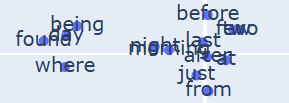